# DepMap pairwise expression analysis for CDK1, MASTL, and PPP2R2A

This notebook reproduces the *style* of a TCGA-like pairwise expression comparison, but uses the **local DepMap database** and the project's **Polars export API** rather than direct CSV munging.

Genes analysed:
- **CDK1**
- **Greatwall / MASTL**
- **PPP2R2A** (B55α)

For each pair, points are coloured by the same legend semantics requested for the original figure:

$$\mathrm{diff} = \frac{x - y}{x + y}$$

where `x` and `y` are the plotted expression values. Pearson correlation `r` is reported on each panel.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import polars as pl

import depmap_db
from depmap_db.analysis.expression_pairs import (
    GENE_ALIASES,
    build_expression_dataset,
    build_highlight_table,
    exact_model_matches,
    nearest_model_candidates,
    pairwise_frame,
    pearson_r,
)

plt.style.use('seaborn-v0_8-whitegrid')
DATASET_LABEL = 'DepMap local DB via depmap_db.polars'
PROJECT_ROOT = Path(depmap_db.__file__).resolve().parents[2]
DB_PATH = PROJECT_ROOT / 'data' / 'depmap.duckdb'
POLARS_SNAPSHOT_DIR = PROJECT_ROOT / 'data' / 'polars'
print(f'Project root: {PROJECT_ROOT}')
print(f'DB path: {DB_PATH}')


Project root: /Users/hh65/code/depmap-db
DB path: /Users/hh65/code/depmap-db/data/depmap.duckdb


In [2]:
data = build_expression_dataset(db_path=DB_PATH, output_dir=POLARS_SNAPSHOT_DIR)
print(f'Models loaded: {data.height:,}')
data.select(['model_id', 'cell_line_name', 'ccle_name', 'CDK1', 'MASTL', 'PPP2R2A']).head(5)

2026-03-28 07:46:52,081 - depmap_db.database.connection - INFO - connection.py:40 - Connecting to database: /Users/hh65/code/depmap-db/data/depmap.duckdb


2026-03-28 07:46:52,562 - depmap_db.database.connection - INFO - connection.py:61 - Database connection established successfully


2026-03-28 07:46:52,617 - depmap_db.database.connection - INFO - connection.py:70 - Database connection closed


Models loaded: 1,699


model_id,cell_line_name,ccle_name,CDK1,MASTL,PPP2R2A
str,str,str,f64,f64,f64
"""ACH-001435""","""1156QE/8""","""1156QE8_TESTIS""",6.470644,2.967176,5.888855
"""ACH-001270""","""1273/99""","""127399_SOFT_TISSUE""",7.872472,4.0923,5.87577
"""ACH-001001""","""143B""","""143B_BONE""",7.833693,4.243463,6.151506
"""ACH-001437""","""1618-K""","""1618K_TESTIS""",6.878051,3.897792,4.382052
"""ACH-002680""","""170-MG-BA""","""170MGBA_CENTRAL_NERVOUS_SYSTEM""",5.260643,3.107758,6.635931


## Check whether HELA and RPE-1 are actually present

The request explicitly asked not to fake these highlights. The code below checks for exact-ish matches after punctuation-insensitive normalisation (for example `RPE-1` → `RPE1`). If a target is absent, the notebook reports nearest available model-name matches instead.

In [3]:
targets = ['HELA', 'RPE-1']
target_report = {}
for target in targets:
    exact_hits = exact_model_matches(data, target)
    nearby = nearest_model_candidates(data, target, limit=6)
    target_report[target] = {'exact': exact_hits, 'nearby': nearby}
    print(f'\n=== {target} ===')
    if exact_hits.height:
        print('Exact match(es) found:')
        display(exact_hits.select(['model_id', 'cell_line_name', 'ccle_name', 'depmap_model_type', 'oncotree_lineage']))
    else:
        print('No exact match found in the local DepMap DB.')
        if nearby.height:
            print('Nearest available model-name matches:')
            display(nearby.select(['model_id', 'cell_line_name', 'ccle_name', 'depmap_model_type', 'oncotree_lineage']))



=== HELA ===
Exact match(es) found:


model_id,cell_line_name,ccle_name,depmap_model_type,oncotree_lineage
str,str,str,str,str
"""ACH-001086""","""HeLa""","""HELA_CERVIX""","""ECAD""","""Cervix"""



=== RPE-1 ===
No exact match found in the local DepMap DB.
Nearest available model-name matches:


model_id,cell_line_name,ccle_name,depmap_model_type,oncotree_lineage
str,str,str,str,str
"""ACH-002466""","""RPE1-ss111""","""RPE1SS111_ENGINEERED""","""ZIMMEPCRT""","""Eye"""
"""ACH-002465""","""RPE1-ss119""","""RPE1SS119_ENGINEERED""","""ZIMMEPCRT""","""Eye"""
"""ACH-002462""","""RPE1-ss48""","""RPE1SS48_ENGINEERED""","""ZIMMEPCRT""","""Eye"""
"""ACH-002467""","""RPE1-ss51""","""RPE1SS51_ENGINEERED""","""ZIMMEPCRT""","""Eye"""
"""ACH-002464""","""RPE1-ss6""","""RPE1SS6_ENGINEERED""","""ZIMMEPCRT""","""Eye"""
"""ACH-002463""","""RPE1-ss77""","""RPE1SS77_ENGINEERED""","""ZIMMEPCRT""","""Eye"""


## Pairwise scatterplots

Each panel uses DepMap expression values from the local database. The point colour is `diff = (x - y) / (x + y)`, and the panel title reports Pearson correlation `r`. Exact highlight matches are overplotted and labelled.

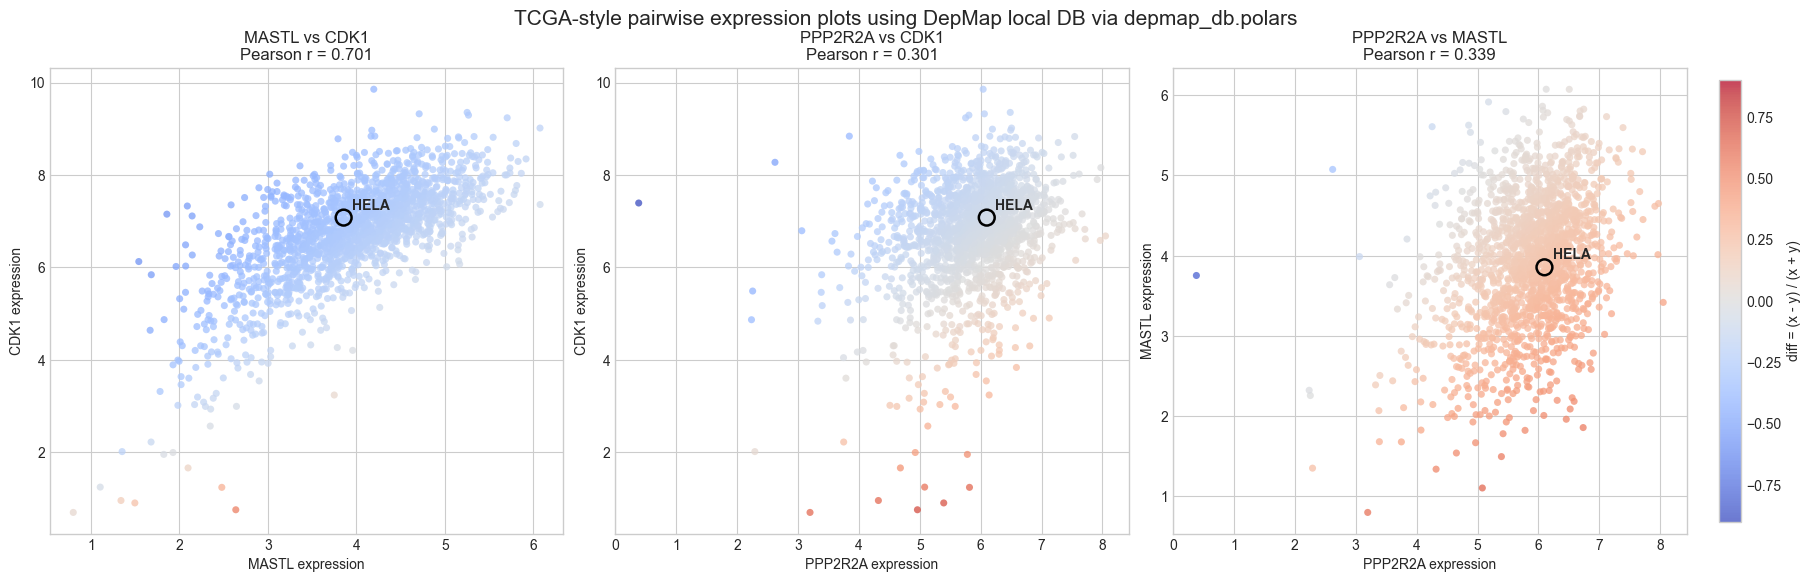

In [4]:
pairs = [
    ('MASTL', 'CDK1'),
    ('PPP2R2A', 'CDK1'),
    ('PPP2R2A', 'MASTL'),
]

highlight_labels = {}
for target, info in target_report.items():
    exact_hits = info['exact']
    if exact_hits.height == 0:
        continue
    for row in exact_hits.select(['model_id', 'cell_line_name']).iter_rows(named=True):
        highlight_labels[row['model_id']] = target

pair_frames = {pair: pairwise_frame(data, *pair) for pair in pairs}
all_diff = pl.concat(list(pair_frames.values()))['diff'].drop_nulls()
max_abs_diff = float(max(abs(all_diff.min()), abs(all_diff.max())))
norm = TwoSlopeNorm(vmin=-max_abs_diff, vcenter=0.0, vmax=max_abs_diff)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
scatter_artist = None

for ax, (x_gene, y_gene) in zip(axes, pairs, strict=True):
    frame = pair_frames[(x_gene, y_gene)]
    pdf = frame.to_pandas()
    scatter_artist = ax.scatter(
        pdf['x'],
        pdf['y'],
        c=pdf['diff'],
        cmap='coolwarm',
        norm=norm,
        s=26,
        alpha=0.75,
        linewidths=0,
    )

    for row in frame.filter(pl.col('model_id').is_in(list(highlight_labels))).iter_rows(named=True):
        ax.scatter(
            row['x'],
            row['y'],
            s=130,
            facecolors='none',
            edgecolors='black',
            linewidths=1.8,
            zorder=5,
        )
        ax.annotate(
            highlight_labels[row['model_id']],
            (row['x'], row['y']),
            xytext=(6, 6),
            textcoords='offset points',
            fontsize=10,
            weight='bold',
        )

    r_value = pearson_r(frame)
    ax.set_title(f'{x_gene} vs {y_gene}\nPearson r = {r_value:.3f}')
    ax.set_xlabel(f'{x_gene} expression')
    ax.set_ylabel(f'{y_gene} expression')

cbar = fig.colorbar(scatter_artist, ax=axes, shrink=0.95, pad=0.02)
cbar.set_label('diff = (x - y) / (x + y)')
fig.suptitle(f'TCGA-style pairwise expression plots using {DATASET_LABEL}', fontsize=15, y=1.03)
plt.show()

## Highlighted-model summary table

This table only includes models that were actually found as exact matches. If a requested highlight target is absent, it is intentionally omitted here rather than imputed.

In [5]:
highlight_table = build_highlight_table(data)
if highlight_table.height:
    highlight_table
else:
    print('No exact highlight models were present in the current DepMap database.')

## Interpretation notes

- **HELA** is present in this local DepMap database and is highlighted on the scatterplots.
- **RPE-1** is **not** present as an exact model in this local DepMap database, so it is **not highlighted**.
- Nearby model-name matches suggest engineered **RPE1-ss*** entries are available; those are shown above as related candidates, not substitutes.
- If you want stricter comparability to a particular publication panel, the next refinement would be to subset models by lineage or disease context before plotting.